In [ ]:
# 数据预处理通用导入
import os, re, time, random, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from concurrent.futures import ThreadPoolExecutor, as_completed
import importlib

In [5]:
# 天文数据与预处理相关导入
import warnings
import scipy
from scipy import signal
from scipy.interpolate import splev, splrep
import astropy.io.fits as afits
from astropy.io import fits
import astropy.units as u
from astropy.coordinates import SkyCoord

warnings.filterwarnings('ignore')
plt.rcParams.update({'axes.labelsize': 'x-large'})

# Data Processing (Masked-band Clustering)

In [ ]:
# Full preprocessing pipeline (same as XGBoost — masked band clustering)

# --- 路径修复：notebook 在 Base/ 下，数据在 Data/ 下 ---
import os as _os, sys as _sys
if _os.path.basename(_os.getcwd()) == 'Base':
    _os.chdir('..')
if 'Base' not in _sys.path:
    _sys.path.insert(0, 'Base')

def _find(path):
    """自动检测 Data/ 子目录前缀。"""
    if _os.path.exists(path):
        return path
    alt = _os.path.join('Data', path)
    if _os.path.exists(alt):
        return alt
    return path

import spectra as _sio
importlib.reload(_sio)

if hasattr(_sio, 'run_screening_preprocess_from_files'):
    run_pipeline_from_files = _sio.run_screening_preprocess_from_files
    _use_file_wrapper = True
elif hasattr(_sio, 'run_screening_preprocess_pipeline'):
    run_screening_preprocess_pipeline = _sio.run_screening_preprocess_pipeline
    _use_file_wrapper = False
else:
    raise ImportError('spectra_io 中未找到可用的预处理管线函数。')

if hasattr(_sio, 'export_spectra_csv'):
    export_spectra_csv = _sio.export_spectra_csv
else:
    export_spectra_csv = _sio.export_datacube_csv

common_wave = np.arange(3800.0, 4500.0, 1.0)

if _use_file_wrapper:
    pipe = run_pipeline_from_files(
        stars_csv=_find('stars.csv'), common_wave=common_wave, folder=_find('dr13_new'),
        cn_catalogs=[_find('CNstar.csv'), _find('FT_cands.csv')], cn_match_tolerance_arcsec=1.0,
        uid_col='uid', snr_col='snru',
        anomaly_low_pct=0.5, anomaly_high_pct=99.5, show_progress=True,
    )
else:
    if 'stars_df' not in globals():
        stars_df = pd.read_csv(_find('stars.csv'))
    pipe = run_screening_preprocess_pipeline(
        stars_df=stars_df, common_wave=common_wave, folder=_find('dr13_new'),
        cn_catalogs=[_find('CNstar.csv'), _find('FT_cands.csv')], cn_match_tolerance_arcsec=1.0,
        uid_col='uid', snr_col='snru',
        anomaly_low_pct=0.5, anomaly_high_pct=99.5, show_progress=True,
    )

X_clean = pipe['datacube_clean']
stars_clean = pipe['stars_clean']
stars_df = pipe.get('stars_stage_dropna_labeled', stars_clean.copy())

print('summary:', pipe['summary'])
print('label_report:', pipe['label_report'])
print('X_clean shape:', X_clean.shape, 'stars_clean shape:', stars_clean.shape)

# KNN + Masked-band Clustering

In [7]:
# KNN + 分子带掩盖聚类约束（与 XGBoost 完全相同的聚类策略）
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

knn_param_cols = ['teff', 'logg', 'feh', 'mag_ps_g', 'snru']
knn_param_cols = [c for c in knn_param_cols if c in stars_clean.columns]
if len(knn_param_cols) < 3:
    raise RuntimeError(f'可用于KNN中心向量的列不足，当前仅有: {knn_param_cols}')

param_df = stars_clean[knn_param_cols].apply(pd.to_numeric, errors='coerce')
param_df = param_df.fillna(param_df.median(numeric_only=True))

scaler = StandardScaler()
X_params_scaled = scaler.fit_transform(param_df.values)

# Step 1: 掩盖CN/CH波段 → PCA降维 → KMeans聚类
masked_cube = np.asarray(X_clean, dtype=float).copy()
for l1, l2 in [(3830, 3883), (4120, 4216), (4285, 4315)]:
    m = (common_wave >= l1) & (common_wave <= l2)
    fill_vals = np.nanmedian(masked_cube[:, ~m], axis=1)
    fill_vals = np.where(np.isfinite(fill_vals), fill_vals, 1.0)
    masked_cube[:, m] = fill_vals[:, None]

n_samples = masked_cube.shape[0]
n_components_masked = int(min(25, masked_cube.shape[1], max(2, n_samples - 1)))
X_masked_emb = PCA(n_components=n_components_masked, random_state=42).fit_transform(masked_cube)

n_clusters_masked = int(np.clip(np.sqrt(n_samples) / 2, 10, 45))
kmeans_masked = KMeans(n_clusters=n_clusters_masked, random_state=42, n_init=20)
masked_labels = kmeans_masked.fit_predict(X_masked_emb)
stars_clean['masked_cluster_id'] = masked_labels

# Step 2: 簇优先KNN（簇内不足时全局补齐）
K = 180
global_knn = NearestNeighbors(n_neighbors=min(K + 1, len(stars_clean)), metric='euclidean', algorithm='auto')
global_knn.fit(X_params_scaled)
global_distances, global_indices = global_knn.kneighbors(X_params_scaled)

neighbor_indices_all, neighbor_distances_all = [], []
for i in range(len(stars_clean)):
    cid = masked_labels[i]
    local_idx = np.where(masked_labels == cid)[0]
    if len(local_idx) >= 3:
        local_X = X_params_scaled[local_idx]
        local_k = min(K + 1, len(local_idx))
        local_knn = NearestNeighbors(n_neighbors=local_k, metric='euclidean', algorithm='auto')
        local_knn.fit(local_X)
        local_pos = int(np.where(local_idx == i)[0][0])
        d_loc, idx_loc = local_knn.kneighbors(local_X[local_pos].reshape(1, -1))
        nb_local = local_idx[idx_loc[0]]
        dd_local = d_loc[0]
        keep = nb_local != i
        nb = nb_local[keep].tolist()
        dd = dd_local[keep].tolist()
    else:
        nb, dd = [], []
    if len(nb) < K:
        g_nb = global_indices[i, 1:].tolist()
        g_dd = global_distances[i, 1:].tolist()
        for j, d in zip(g_nb, g_dd):
            if j not in nb:
                nb.append(int(j)); dd.append(float(d))
            if len(nb) >= K: break
    neighbor_indices_all.append(np.asarray(nb[:K], dtype=int))
    neighbor_distances_all.append(np.asarray(dd[:K], dtype=float))

stars_clean['neighbor_indices'] = neighbor_indices_all
stars_clean['neighbor_distances'] = neighbor_distances_all

# Step 3: KNN中心向量与距离特征
center_scaled = np.zeros_like(X_params_scaled, dtype=float)
center_euclid = np.full(len(stars_clean), np.nan, dtype=float)
for i, nb in enumerate(stars_clean['neighbor_indices']):
    nb = np.asarray(nb, dtype=int)
    if nb.size == 0: continue
    local_center = X_params_scaled[nb].mean(axis=0)
    center_scaled[i] = local_center
    center_euclid[i] = np.linalg.norm(X_params_scaled[i] - local_center)

center_orig = scaler.inverse_transform(center_scaled)
for j, col in enumerate(knn_param_cols):
    stars_clean[f'knn_center_{col}'] = center_orig[:, j]

stars_clean['knn_center_euclid'] = center_euclid
dist_rank = pd.Series(center_euclid).rank(pct=True, method='average')
stars_clean['knn_euclid_prob'] = dist_rank.clip(0.0, 1.0).values
dist_med = np.nanmedian(center_euclid)
dist_mad = np.nanmedian(np.abs(center_euclid - dist_med)) + 1e-12
stars_clean['knn_center_dist_z'] = (center_euclid - dist_med) / (1.4826 * dist_mad)

print(f'KNN features: {knn_param_cols}, K={K}, masked_clusters={n_clusters_masked}')

KNN features: ['teff', 'logg', 'feh', 'mag_ps_g', 'snru'], K=180, masked_clusters=45


# CN/CH Band Index Features

In [8]:
# 基础特征表（仅保留核心列）
base_cols = [
    'teff', 'logg', 'feh', 'label', 'snru', 'mag_ps_g',
    'knn_center_euclid', 'knn_euclid_prob', 'knn_center_dist_z',
    'knn_center_teff', 'knn_center_logg', 'knn_center_feh', 'filepath',
]
base_cols = [c for c in base_cols if c in stars_clean.columns]
feature_df = stars_clean[base_cols].copy()
print('Base columns:', feature_df.columns.tolist())

Base columns: ['teff', 'logg', 'feh', 'label', 'snru', 'mag_ps_g', 'knn_center_euclid', 'knn_euclid_prob', 'knn_center_dist_z', 'knn_center_teff', 'knn_center_logg', 'knn_center_feh', 'filepath']


In [9]:
# 计算 CN/CH 指数
def safe_mean(x):
    x = np.asarray(x, dtype=float); x = x[np.isfinite(x)]
    return np.mean(x) if len(x) > 0 else np.nan

def compute_band_index(wave, flux, band, blue, red):
    wave, flux = np.asarray(wave, dtype=float), np.asarray(flux, dtype=float)
    band_mask = (wave >= band[0]) & (wave <= band[1])
    blue_mask = (wave >= blue[0]) & (wave <= blue[1])
    red_mask  = (wave >= red[0])  & (wave <= red[1])
    F_band = safe_mean(flux[band_mask])
    F_blue = safe_mean(flux[blue_mask])
    F_red  = safe_mean(flux[red_mask])
    if not all(np.isfinite(v) for v in [F_band, F_blue, F_red]):
        return np.nan
    F_cont = 0.5 * (F_blue + F_red)
    if F_band <= 0 or F_cont <= 0: return np.nan
    return -2.5 * np.log10(F_band / F_cont)

band_defs = {
    'CN3839': {'band': (3830, 3883), 'blue': (3894, 3910), 'red': (4000, 4020)},
    'CN4142': {'band': (4120, 4216), 'blue': (4055, 4080), 'red': (4240, 4280)},
    'CH4300': {'band': (4285, 4315), 'blue': (4240, 4280), 'red': (4390, 4460)},
}

cn3839_list, cn4142_list, ch4300_list = [], [], []
for i in range(len(X_clean)):
    flux = X_clean[i]
    cn3839_list.append(compute_band_index(common_wave, flux, 
        band_defs['CN3839']['band'], band_defs['CN3839']['blue'], band_defs['CN3839']['red']))
    cn4142_list.append(compute_band_index(common_wave, flux, 
        band_defs['CN4142']['band'], band_defs['CN4142']['blue'], band_defs['CN4142']['red']))
    ch4300_list.append(compute_band_index(common_wave, flux, 
        band_defs['CH4300']['band'], band_defs['CH4300']['blue'], band_defs['CH4300']['red']))

feature_df['CN3839'] = cn3839_list
feature_df['CN4142'] = cn4142_list
feature_df['CH4300'] = ch4300_list
print(feature_df[['CN3839', 'CN4142', 'CH4300']].describe())

             CN3839        CN4142        CH4300
count  33589.000000  33589.000000  33589.000000
mean       0.115798      0.001370      0.188518
std        0.078069      0.010701      0.038305
min       -0.497339     -0.241090     -0.216691
25%        0.048360     -0.003480      0.170223
50%        0.109510      0.001023      0.194942
75%        0.176445      0.005466      0.213473
max        0.516198      0.157739      1.482771


In [10]:
# 构造邻居中位数差分特征（CN增强相对同类星）
def neighbor_median(values, neighbor_idx):
    vals = values[np.asarray(neighbor_idx, dtype=int)]
    vals = vals[np.isfinite(vals)]
    return np.median(vals) if len(vals) > 0 else np.nan

cn3839_arr = feature_df['CN3839'].values
cn4142_arr = feature_df['CN4142'].values
ch4300_arr = feature_df['CH4300'].values

med_cn3839 = [neighbor_median(cn3839_arr, nb) for nb in stars_clean['neighbor_indices']]
med_cn4142 = [neighbor_median(cn4142_arr, nb) for nb in stars_clean['neighbor_indices']]
med_ch4300 = [neighbor_median(ch4300_arr, nb) for nb in stars_clean['neighbor_indices']]

feature_df['nb_med_CN3839'] = med_cn3839
feature_df['nb_med_CN4142'] = med_cn4142
feature_df['nb_med_CH4300'] = med_ch4300

feature_df['delta_CN3839'] = feature_df['CN3839'] - feature_df['nb_med_CN3839']
feature_df['delta_CN4142'] = feature_df['CN4142'] - feature_df['nb_med_CN4142']
feature_df['delta_CH4300'] = feature_df['CH4300'] - feature_df['nb_med_CH4300']

# 物理参数差分（相对KNN邻居中心）
if 'knn_center_teff' in feature_df.columns:
    feature_df['delta_teff_center'] = feature_df['teff'] - feature_df['knn_center_teff']
if 'knn_center_logg' in feature_df.columns:
    feature_df['delta_logg_center'] = feature_df['logg'] - feature_df['knn_center_logg']
if 'knn_center_feh' in feature_df.columns:
    feature_df['delta_feh_center'] = feature_df['feh'] - feature_df['knn_center_feh']

print(feature_df[['delta_CN3839', 'delta_CN4142', 'delta_CH4300']].describe())

       delta_CN3839  delta_CN4142  delta_CH4300
count  33589.000000  33589.000000  33589.000000
mean       0.001014      0.000629     -0.000718
std        0.029592      0.009974      0.021745
min       -0.516894     -0.243373     -0.381729
25%       -0.014604     -0.003369     -0.009005
50%        0.000031      0.000139     -0.000576
75%        0.015389      0.003796      0.007333
max        0.344126      0.159668      1.285397


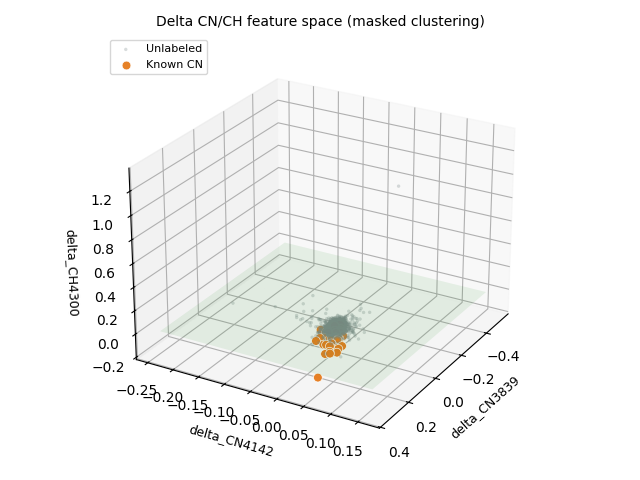

In [11]:
# 3D 散点图：delta_CN特征空间中的已知CN星 vs 未标注星
from mpl_toolkits.mplot3d import Axes3D
%matplotlib widget

plot_df = feature_df[['delta_CN3839', 'delta_CN4142', 'delta_CH4300', 'label']].copy()
plot_df = plot_df.replace([np.inf, -np.inf], np.nan).dropna()

cn_df_plot = plot_df[plot_df['label'] == 1]
unl_df_plot = plot_df[plot_df['label'] == -1]
if len(unl_df_plot) > 3000:
    unl_df_plot = unl_df_plot.sample(3000, random_state=42)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# 零点参考面
x_min, x_max = plot_df['delta_CN3839'].min(), plot_df['delta_CN3839'].max()
y_min, y_max = plot_df['delta_CN4142'].min(), plot_df['delta_CN4142'].max()
z_min, z_max = plot_df['delta_CH4300'].min(), plot_df['delta_CH4300'].max()
x_grid, y_grid = np.meshgrid(np.linspace(x_min, x_max, 10), np.linspace(y_min, y_max, 10))
ax.plot_surface(x_grid, y_grid, np.zeros_like(x_grid), color='green', alpha=0.08, shade=False)

ax.scatter(unl_df_plot['delta_CN3839'], unl_df_plot['delta_CN4142'], unl_df_plot['delta_CH4300'],
           c='#7f8c8d', s=6, alpha=0.3, label='Unlabeled', edgecolors='none')
ax.scatter(cn_df_plot['delta_CN3839'], cn_df_plot['delta_CN4142'], cn_df_plot['delta_CH4300'],
           c='#e67e22', s=40, alpha=0.98, label='Known CN', edgecolors='white', linewidth=0.5)

ax.set_xlabel('delta_CN3839', fontsize=9)
ax.set_ylabel('delta_CN4142', fontsize=9)
ax.set_zlabel('delta_CH4300', fontsize=9)
ax.view_init(elev=25, azim=30)
ax.legend(loc='upper left', fontsize=8)
ax.set_title('Delta CN/CH feature space (masked clustering)', fontsize=10)
plt.tight_layout()
plt.show()

## Feature Selection — 精简化

In [12]:
# PCA 降维 — 仅保留 3 个主成分，避免噪声维度
from sklearn.decomposition import PCA

n_pca = 3
pca = PCA(n_components=n_pca, random_state=42)
X_pca = pca.fit_transform(X_clean)
for i in range(n_pca):
    feature_df[f'pca_{i+1}'] = X_pca[:, i]

print(f'PCA 解释方差累计占比: {pca.explained_variance_ratio_.sum():.3f}')
print(f'各成分解释方差: {pca.explained_variance_ratio_}')

PCA 解释方差累计占比: 0.298
各成分解释方差: [0.22656141 0.0376183  0.03416986]


In [13]:
# =======================================================
# 核心设计思想：大幅精简特征，只用与 CN/CH 分子带直接相关的特征
# + 物理参数 + KNN距离，避免 MLP 在多噪声维度上过拟合
# =======================================================

feature_cols = [
    # ─ 物理参数（3个）
    'teff', 'logg', 'feh',
    # ─ CN/CH 分子带指数（3个）
    'CN3839', 'CN4142', 'CH4300',
    # ─ 差分特征（相对邻居中位数，3个）
    'delta_CN3839', 'delta_CN4142', 'delta_CH4300',
    # ─ KNN 距离（反映该星在参数空间中是否孤立，2个）
    'knn_center_euclid', 'knn_center_dist_z',
    # ─ PCA 前3主成分（捕获光谱整体形态，3个）
    'pca_1', 'pca_2', 'pca_3',
]
feature_cols = [c for c in feature_cols if c in feature_df.columns]

print(f'特征总数: {len(feature_cols)}')
print('特征列表:')
for i, c in enumerate(feature_cols, 1):
    print(f'  {i:2d}. {c}')

特征总数: 14
特征列表:
   1. teff
   2. logg
   3. feh
   4. CN3839
   5. CN4142
   6. CH4300
   7. delta_CN3839
   8. delta_CN4142
   9. delta_CH4300
  10. knn_center_euclid
  11. knn_center_dist_z
  12. pca_1
  13. pca_2
  14. pca_3


## ML Imports & Utilities

In [14]:
# 机器学习导入与工具函数
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_fscore_support,
    roc_curve, precision_recall_curve
)

def prepare_model_data(df_input, feat_cols, random_state=42, test_size=0.2):
    df = df_input.dropna(subset=feat_cols + ['label']).copy()
    X = df[feat_cols].values
    y = df['label'].map({1: 1, -1: 0}).values
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state)
    return df, X_tr, X_te, y_tr, y_te

def topk_metrics(y_true, y_score, topk_list=[50, 100, 200]):
    out = {}
    order = np.argsort(y_score)[::-1]
    y_sorted = y_true[order]
    total_pos = max(int((y_true == 1).sum()), 1)
    for k in topk_list:
        k_eff = min(k, len(y_sorted))
        y_top = y_sorted[:k_eff]
        out[f'precision@{k}'] = float(y_top.mean()) if k_eff > 0 else np.nan
        out[f'recall@{k}'] = float(y_top.sum() / total_pos)
    return out

def evaluate_binary(name, y_true, y_prob, threshold=0.5, topk_list=[50, 100, 200]):
    y_pred = (y_prob >= threshold).astype(int)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', zero_division=0)
    return {
        'model': name,
        'ROC_AUC': roc_auc_score(y_true, y_prob),
        'PR_AUC': average_precision_score(y_true, y_prob),
        'Precision': p, 'Recall': r, 'F1': f1,
        **topk_metrics(y_true, y_prob, topk_list)
    }

def attach_stars_metadata(df_in, stars_df):
    cols = ['filepath', 'uid', 'ra', 'dec', 'teff', 'logg', 'feh', 'rv', 'snru',
            'snrg', 'mag_ps_g', 'neighbor_indices', 'knn_euclid_prob']
    df = df_in.copy()
    use_cols = [c for c in cols if c in stars_df.columns]
    if not use_cols: return df
    if 'filepath' in df.columns and 'filepath' in stars_df.columns:
        map_df = stars_df[use_cols].drop_duplicates(subset=['filepath'])
        df = df.merge(map_df, on='filepath', how='left', suffixes=('', '_meta'))
    for c in use_cols:
        c_meta = f'{c}_meta'
        if c_meta in df.columns and c not in df.columns:
            df[c] = df[c_meta]
        if c_meta in df.columns and c in df.columns:
            miss = df[c].isna() if hasattr(df[c], 'isna') else pd.Series(np.zeros(len(df)), dtype=bool, index=df.index)
            df.loc[miss, c] = df.loc[miss, c_meta]
    drop_cols = [f'{c}_meta' for c in use_cols if f'{c}_meta' in df.columns]
    if drop_cols: df = df.drop(columns=drop_cols)
    return df

## MLP Architecture Comparison — 过拟合诊断

**核心目的**：用相同的精简特征集，对比不同规模的 MLP，
诊断过拟合程度（train/val gap 越大 → 过拟合越严重）

In [15]:
# MLP 架构对比实验：测试不同规模的网络
import copy
df_model, X_train, X_test, y_train, y_test = prepare_model_data(
    feature_df, feature_cols, random_state=42, test_size=0.2)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Train pos: {int((y_train==1).sum())}, Test pos: {int((y_test==1).sum())}')
print(f'正负比: 1:{int((y_train==0).sum() / max((y_train==1).sum(), 1))}')

# 用上采样平衡训练集
n_pos = int((y_train == 1).sum())
n_neg = int((y_train == 0).sum())

# ---------- 定义不同规模的MLP ----------
architectures = {
    'MLP_tiny_8':        {'hidden': (8,),             'alpha': 1e-3, 'lr': 5e-4, 'label': 'Tiny (8)'},
    'MLP_small_16_8':    {'hidden': (16, 8),          'alpha': 5e-3, 'lr': 3e-4, 'label': 'Small (16,8)'},
    'MLP_medium_32_16':  {'hidden': (32, 16),         'alpha': 8e-3, 'lr': 2e-4, 'label': 'Medium (32,16)'},
    'MLP_ref_64_32':     {'hidden': (64, 32),         'alpha': 1e-2, 'lr': 1e-4, 'label': 'Ref (64,32) — MLP_3p级'},  
}

RANDOM_STATE = 42
TOPK_LIST = [50, 100, 200]
MAX_EPOCHS = 200  # warm_start 多轮训练总轮数

# 固定验证集（用于公平比较）
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=RANDOM_STATE)

all_histories = {}
all_results = []

for arch_name, cfg in architectures.items():
    print(f'\n{"="*60}')
    print(f'Training: {cfg["label"]}')
    print(f'{"="*60}')

    # 上采样正样本
    pos_mask = (y_tr == 1)
    neg_mask = (y_tr == 0)
    X_tr_pos, y_tr_pos = X_tr[pos_mask], y_tr[pos_mask]
    X_tr_neg, y_tr_neg = X_tr[neg_mask], y_tr[neg_mask]

    up_factor = max(1, int(np.ceil(len(y_tr_neg) / max(len(y_tr_pos), 1) / 8)))  # 控制正负比约1:8
    X_pos_up = np.repeat(X_tr_pos, up_factor, axis=0)
    y_pos_up = np.repeat(y_tr_pos, up_factor, axis=0)
    X_bal = np.vstack([X_tr_neg, X_pos_up])
    y_bal = np.concatenate([y_tr_neg, y_pos_up])

    scaler = StandardScaler()
    X_bal_s = scaler.fit_transform(X_bal)
    X_val_s = scaler.transform(X_val)
    X_test_s = scaler.transform(X_test)

    model = MLPClassifier(
        hidden_layer_sizes=cfg['hidden'], activation='relu', solver='adam',
        alpha=cfg['alpha'], learning_rate_init=cfg['lr'],
        batch_size=128, max_iter=1, warm_start=True, shuffle=True,
        random_state=RANDOM_STATE, early_stopping=False,  # 手动控制
    )

    history = {'epoch': [], 'train_loss': [], 'val_loss': [],
               'train_pr': [], 'val_pr': [], 'train_roc': [], 'val_roc': []}
    best_val_pr = -np.inf; best_model = None; best_epoch = 0
    patience, no_improve = 30, 0

    for epoch in range(1, MAX_EPOCHS + 1):
        model.fit(X_bal_s, y_bal)
        tr_prob = model.predict_proba(X_bal_s)[:, 1]
        va_prob = model.predict_proba(X_val_s)[:, 1]

        tr_pr = average_precision_score(y_bal, tr_prob)
        va_pr = average_precision_score(y_val, va_prob)
        tr_roc = roc_auc_score(y_bal, tr_prob)
        va_roc = roc_auc_score(y_val, va_prob)

        history['epoch'].append(epoch)
        history['train_loss'].append(model.loss_)
        history['train_pr'].append(tr_pr)
        history['val_pr'].append(va_pr)
        history['train_roc'].append(tr_roc)
        history['val_roc'].append(va_roc)

        if va_pr > best_val_pr:
            best_val_pr = va_pr; best_epoch = epoch
            best_model = copy.deepcopy(model)
            no_improve = 0
        else:
            no_improve += 1

        if no_improve >= patience: break

    # 用最佳模型评估
    model = best_model
    te_prob = model.predict_proba(X_test_s)[:, 1]
    va_prob_best = model.predict_proba(X_val_s)[:, 1]

    result = evaluate_binary(cfg['label'], y_test, te_prob, topk_list=TOPK_LIST)
    result['best_epoch'] = best_epoch
    result['train_pr_final'] = history['train_pr'][best_epoch - 1]
    result['val_pr_best'] = best_val_pr
    result['pr_gap'] = history['train_pr'][best_epoch - 1] - best_val_pr  # 过拟合指标
    result['total_epochs'] = len(history['epoch'])
    all_results.append(result)
    all_histories[arch_name] = history

    print(f'  Best epoch: {best_epoch}/{len(history["epoch"])}')
    print(f'  Val PR-AUC: {best_val_pr:.4f}, Train PR-AUC: {history["train_pr"][best_epoch-1]:.4f}')
    print(f'  PR Gap (overfit): {result["pr_gap"]:.4f}')
    print(f'  Test PR-AUC: {result["PR_AUC"]:.4f}, ROC-AUC: {result["ROC_AUC"]:.4f}')

# ── 汇总对比表 ──
result_df = pd.DataFrame(all_results).sort_values('val_pr_best', ascending=False)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
print('\n' + '='*60)
print('SUMMARY: MLP Architecture Comparison')
print('='*60)
display(result_df[[
    'model', 'ROC_AUC', 'PR_AUC', 'Precision', 'Recall', 'F1',
    'precision@50', 'precision@100', 'val_pr_best', 'pr_gap', 'best_epoch', 'total_epochs',
]].round(4))

Train: (26871, 14), Test: (6718, 14)
Train pos: 58, Test pos: 15
正负比: 1:462

Training: Tiny (8)
  Best epoch: 22/52
  Val PR-AUC: 0.2396, Train PR-AUC: 0.9471
  PR Gap (overfit): 0.7074
  Test PR-AUC: 0.2605, ROC-AUC: 0.9879

Training: Small (16,8)
  Best epoch: 96/126
  Val PR-AUC: 0.3345, Train PR-AUC: 0.9904
  PR Gap (overfit): 0.6559
  Test PR-AUC: 0.1368, ROC-AUC: 0.8538

Training: Medium (32,16)
  Best epoch: 18/48
  Val PR-AUC: 0.2423, Train PR-AUC: 0.9745
  PR Gap (overfit): 0.7322
  Test PR-AUC: 0.2030, ROC-AUC: 0.9547

Training: Ref (64,32) — MLP_3p级
  Best epoch: 2/32
  Val PR-AUC: 0.2254, Train PR-AUC: 0.8434
  PR Gap (overfit): 0.6180
  Test PR-AUC: 0.2538, ROC-AUC: 0.9701

SUMMARY: MLP Architecture Comparison


,model,ROC_AUC,PR_AUC,Precision,Recall,F1,precision@50,precision@100,val_pr_best,pr_gap,best_epoch,total_epochs
1,"Small (16,8)",0.8538,0.1368,0.1923,0.3333,0.2439,0.12,0.06,0.3345,0.6559,96,126
2,"Medium (32,16)",0.9547,0.2030,0.1373,0.4667,0.2121,0.14,0.08,0.2423,0.7322,18,48
0,Tiny (8),0.9879,0.2605,0.1467,0.7333,0.2444,0.16,0.13,0.2396,0.7074,22,52
3,"Ref (64,32) — MLP_3p级",0.9701,0.2538,0.1176,0.5333,0.1928,0.12,0.08,0.2254,0.6180,2,32


## Overfitting Diagnosis — 训练曲线对比

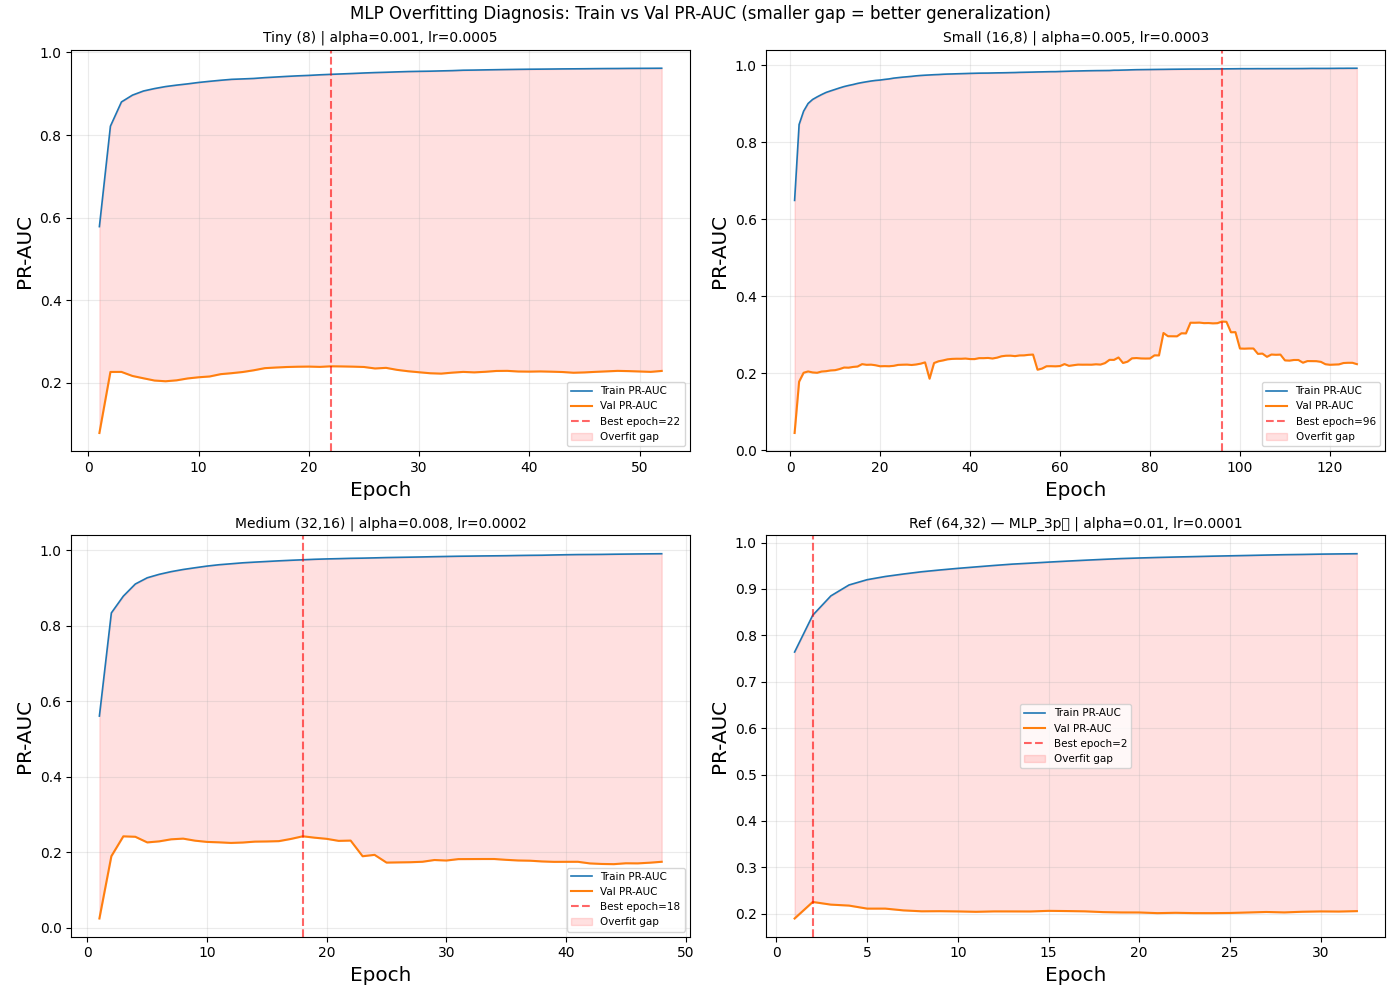

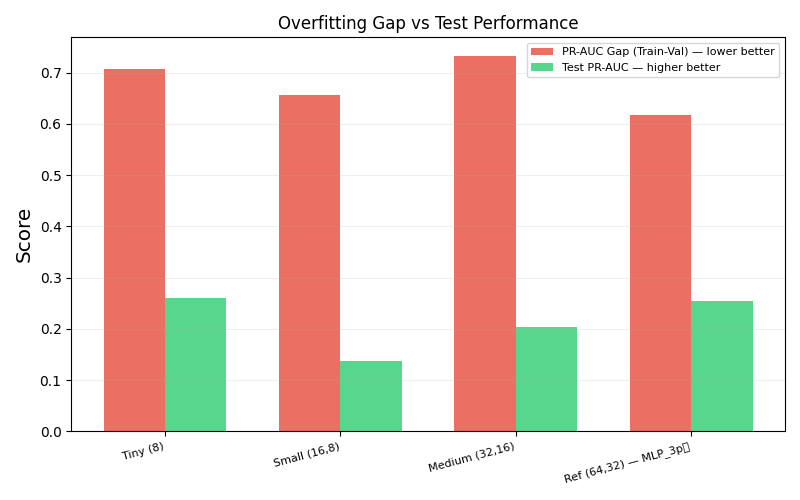

In [16]:
# 过拟合诊断图：训练/验证 PR-AUC 曲线对比
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (arch_name, cfg) in zip(axes, architectures.items()):
    h = all_histories[arch_name]
    ax.plot(h['epoch'], h['train_pr'], color='tab:blue', linewidth=1.2, label='Train PR-AUC')
    ax.plot(h['epoch'], h['val_pr'], color='tab:orange', linewidth=1.5, label='Val PR-AUC')

    # 标注最佳epoch
    best_idx = np.argmax(h['val_pr'])
    ax.axvline(h['epoch'][best_idx], color='red', linestyle='--', alpha=0.6, label=f'Best epoch={h["epoch"][best_idx]}')

    # 填充过拟合区域
    ax.fill_between(h['epoch'], h['train_pr'], h['val_pr'], alpha=0.12, color='red', label='Overfit gap')

    ax.set_title(f"{cfg['label']} | alpha={cfg['alpha']}, lr={cfg['lr']}", fontsize=10)
    ax.set_xlabel('Epoch'); ax.set_ylabel('PR-AUC')
    ax.grid(alpha=0.25); ax.legend(fontsize=7.5)

for j in range(len(architectures), len(axes)):
    axes[j].axis('off')

fig.suptitle('MLP Overfitting Diagnosis: Train vs Val PR-AUC (smaller gap = better generalization)',
             fontsize=12, y=0.995)
plt.tight_layout(); plt.subplots_adjust(top=0.95); plt.show()

# ── 过拟合指标柱状图 ──
fig, ax = plt.subplots(figsize=(8, 5))
names = [r['model'] for r in all_results]
pr_gaps = [max(0, r['pr_gap']) for r in all_results]
test_prs = [r['PR_AUC'] for r in all_results]

x = np.arange(len(names))
w = 0.35
bars1 = ax.bar(x - w/2, pr_gaps, w, label='PR-AUC Gap (Train-Val) — lower better', color='#e74c3c', alpha=0.8)
bars2 = ax.bar(x + w/2, test_prs, w, label='Test PR-AUC — higher better', color='#2ecc71', alpha=0.8)

ax.set_xticks(x); ax.set_xticklabels(names, rotation=15, ha='right', fontsize=8)
ax.set_ylabel('Score'); ax.set_title('Overfitting Gap vs Test Performance')
ax.grid(alpha=0.2, axis='y'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Best MLP — 多轮训练 + 过拟合监控

选择过拟合最小的架构，做更充分的多轮训练。

Selected best architecture: Ref (64,32) — MLP_3p级 (min PR gap=0.6180)
Hidden: (64, 32), alpha=0.01, lr=0.0001

Best epoch: 150/150
Test PR-AUC: 0.3855, ROC-AUC: 0.9023
Test Precision: 0.3200, Recall: 0.5333
Train PR at best: 0.9952
Val PR at best: 0.9970
PR Gap: -0.0017


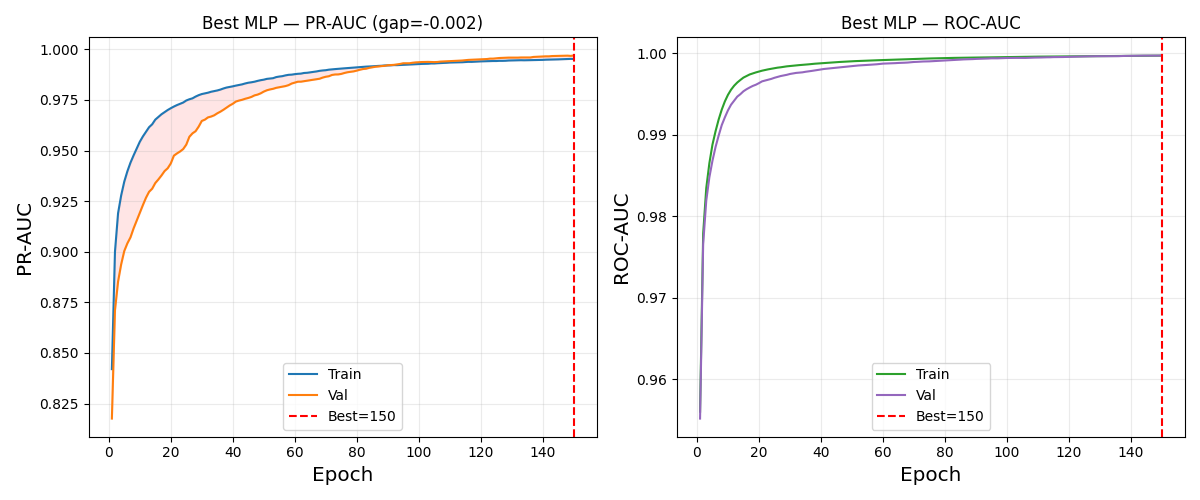

In [17]:
# 选出最优架构，做充分训练 + 全量未标注数据预测
import copy

# 根据对比结果选择（默认取 PR_gap 最小的）
best_row = result_df.loc[result_df['pr_gap'].idxmin()]
best_arch_name = best_row['model']
print(f'Selected best architecture: {best_arch_name} (min PR gap={best_row["pr_gap"]:.4f})')

# 反查架构参数
best_arch_key = [k for k, v in architectures.items() if v['label'] == best_arch_name][0]
best_cfg = architectures[best_arch_key]
print(f'Hidden: {best_cfg["hidden"]}, alpha={best_cfg["alpha"]}, lr={best_cfg["lr"]}')

# 用全部训练数据重新训练最佳架构
N_EPOCHS_FULL = 150
pos_mask = (y_train == 1)
neg_mask = (y_train == 0)
X_tr_pos_f, y_tr_pos_f = X_train[pos_mask], y_train[pos_mask]
X_tr_neg_f, y_tr_neg_f = X_train[neg_mask], y_train[neg_mask]

up_factor = max(1, int(np.ceil(len(y_tr_neg_f) / max(len(y_tr_pos_f), 1) / 8)))
X_pos_up_f = np.repeat(X_tr_pos_f, up_factor, axis=0)
y_pos_up_f = np.repeat(y_tr_pos_f, up_factor, axis=0)
X_bal_f = np.vstack([X_tr_neg_f, X_pos_up_f])
y_bal_f = np.concatenate([y_tr_neg_f, y_pos_up_f])

scaler_full = StandardScaler()
X_bal_f_s = scaler_full.fit_transform(X_bal_f)
X_test_s_f = scaler_full.transform(X_test)

# 分出训练+验证
X_tr_f, X_val_f, y_tr_f, y_val_f = train_test_split(
    X_bal_f_s, y_bal_f, test_size=0.15, stratify=y_bal_f, random_state=42)

model_full = MLPClassifier(
    hidden_layer_sizes=best_cfg['hidden'], activation='relu', solver='adam',
    alpha=best_cfg['alpha'], learning_rate_init=best_cfg['lr'],
    batch_size=64, max_iter=1, warm_start=True, shuffle=True,
    random_state=42,
)

full_history = {'epoch': [], 'train_loss': [], 'train_pr': [], 'val_pr': [],
                'train_roc': [], 'val_roc': []}
best_val_pr_full = -np.inf; best_epoch_full = 0; best_model_full = None
patience_full, no_improve_full = 40, 0

for epoch in range(1, N_EPOCHS_FULL + 1):
    model_full.fit(X_tr_f, y_tr_f)
    tr_prob_f = model_full.predict_proba(X_tr_f)[:, 1]
    va_prob_f = model_full.predict_proba(X_val_f)[:, 1]

    tr_pr_f = average_precision_score(y_tr_f, tr_prob_f)
    va_pr_f = average_precision_score(y_val_f, va_prob_f)
    tr_roc_f = roc_auc_score(y_tr_f, tr_prob_f)
    va_roc_f = roc_auc_score(y_val_f, va_prob_f)

    full_history['epoch'].append(epoch)
    full_history['train_loss'].append(model_full.loss_)
    full_history['train_pr'].append(tr_pr_f)
    full_history['val_pr'].append(va_pr_f)
    full_history['train_roc'].append(tr_roc_f)
    full_history['val_roc'].append(va_roc_f)

    if va_pr_f > best_val_pr_full:
        best_val_pr_full = va_pr_f; best_epoch_full = epoch
        best_model_full = copy.deepcopy(model_full)
        no_improve_full = 0
    else:
        no_improve_full += 1
    if no_improve_full >= patience_full: break

# 测试集评估
te_prob_f = best_model_full.predict_proba(X_test_s_f)[:, 1]
test_result = evaluate_binary('Best MLP (full train)', y_test, te_prob_f)
print(f'\nBest epoch: {best_epoch_full}/{len(full_history["epoch"])}')
print(f'Test PR-AUC: {test_result["PR_AUC"]:.4f}, ROC-AUC: {test_result["ROC_AUC"]:.4f}')
print(f'Test Precision: {test_result["Precision"]:.4f}, Recall: {test_result["Recall"]:.4f}')
print(f'Train PR at best: {full_history["train_pr"][best_epoch_full-1]:.4f}')
print(f'Val PR at best: {best_val_pr_full:.4f}')
print(f'PR Gap: {full_history["train_pr"][best_epoch_full-1] - best_val_pr_full:.4f}')

# 对全量未标注数据打分
unlabeled_mask = feature_df['label'] == -1
unlabeled_df = feature_df[unlabeled_mask].copy()
X_unl = unlabeled_df[feature_cols].values.astype(float)
X_unl_s = scaler_full.transform(X_unl)
unlabeled_df['MLP_prob'] = best_model_full.predict_proba(X_unl_s)[:, 1]

# 训练曲线
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(full_history['epoch'], full_history['train_pr'], label='Train', color='tab:blue')
axes[0].plot(full_history['epoch'], full_history['val_pr'], label='Val', color='tab:orange')
axes[0].axvline(best_epoch_full, color='red', linestyle='--', label=f'Best={best_epoch_full}')
axes[0].fill_between(full_history['epoch'], full_history['train_pr'],
                       full_history['val_pr'], alpha=0.1, color='red')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('PR-AUC')
axes[0].set_title(f'Best MLP — PR-AUC (gap={full_history["train_pr"][best_epoch_full-1] - best_val_pr_full:.3f})')
axes[0].grid(alpha=0.25); axes[0].legend()

axes[1].plot(full_history['epoch'], full_history['train_roc'], label='Train', color='tab:green')
axes[1].plot(full_history['epoch'], full_history['val_roc'], label='Val', color='tab:purple')
axes[1].axvline(best_epoch_full, color='red', linestyle='--', label=f'Best={best_epoch_full}')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('ROC-AUC')
axes[1].set_title('Best MLP — ROC-AUC')
axes[1].grid(alpha=0.25); axes[1].legend()
plt.tight_layout(); plt.show()

## MLP Self-Training — 带物理约束的保守自训练

与之前 MLP 的关键区别：
1. 初始负样本必须从 CN 指数低的可靠负样本池采样
2. 每轮新增伪正数量严格限制（≤15）
3. 伪正样本必须通过物理约束检查
4. 动态阈值，缓慢放宽

Train pos: 58, Unlabeled: 26813, Test: 6718
Reliable negative pool: 6704 (CN index bottom 25%)
Physics constraints: dCN3839>=0.0492, dCN4142>=0.0099, |dCH4300--0.0235|<=0.0356
Round 1: +pos=0, +neg=1,  val_PR=0.7537, th_high=0.970
Round 2: +pos=0, +neg=3,  val_PR=0.5929, th_high=0.952
Round 3: +pos=0, +neg=3,  val_PR=0.7003, th_high=0.934
Round 4: +pos=15, +neg=6,  val_PR=0.7622, th_high=0.916
Round 5: +pos=15, +neg=16,  val_PR=0.6699, th_high=0.898
Round 6: +pos=0, +neg=3,  val_PR=0.5838, th_high=0.880

Best round: 4, Val PR-AUC: 0.7622
Test PR-AUC: 0.2778, ROC-AUC: 0.9674
precision@50: 0.2000, precision@100: 0.1000
Top 300 candidates saved to: mlp_light_candidates_20260517_133811.csv


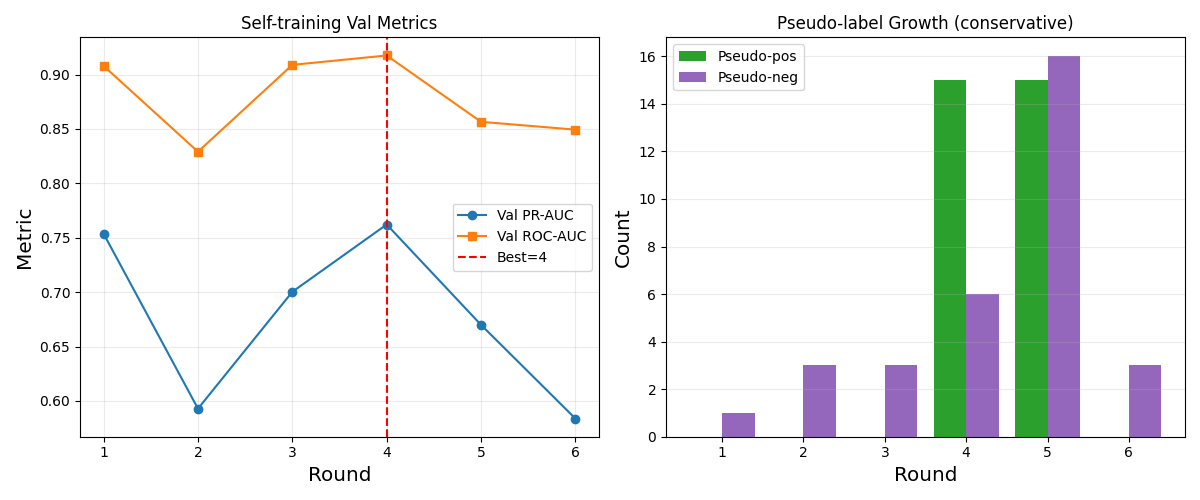

In [18]:
# MLP 保守自训练（修复版）
from datetime import datetime

RNG = np.random.RandomState(42)

# 准备数据
df_st = feature_df.dropna(subset=feature_cols + ['label']).copy()
X_all_st = df_st[feature_cols].values.astype(float)
y_all_st = df_st['label'].map({1: 1, -1: 0}).values

# 分割 — 记录原始 df_st 索引，避免后续索引错位
all_idx = np.arange(len(df_st))
train_idx, test_idx = train_test_split(
    all_idx, test_size=0.2, stratify=y_all_st, random_state=42)
X_tr_st = X_all_st[train_idx]   # X_tr_st[0] = X_all_st[train_idx[0]]
y_tr_st = y_all_st[train_idx]
X_te_st = X_all_st[test_idx]
y_te_st = y_all_st[test_idx]
# 快速映射: df_st位置 → X_tr_st内位置
dfpos_to_trpos = {df_pos: i for i, df_pos in enumerate(train_idx)}

# 以下所有索引均为 df_st 位置（可直接用于 df_st.iloc[]）
pos_idx_st = train_idx[y_tr_st == 1]
unl_idx_st = train_idx[y_tr_st == 0]
print(f'Train pos: {len(pos_idx_st)}, Unlabeled: {len(unl_idx_st)}, Test: {len(y_te_st)}')

# —— 构造可靠负样本种子池（CN指数低者优先） ——
if {'CN3839', 'CN4142'}.issubset(df_st.columns):
    seed_score = df_st.iloc[unl_idx_st]['CN3839'].values + df_st.iloc[unl_idx_st]['CN4142'].values
    q25 = np.nanpercentile(seed_score, 25)
    reliable_neg_pool = unl_idx_st[seed_score <= q25]
else:
    reliable_neg_pool = unl_idx_st.copy()
print(f'Reliable negative pool: {len(reliable_neg_pool)} (CN index bottom 25%)')

# —— 初始化训练集 ——
init_neg_n = min(max(4 * len(pos_idx_st), 200), len(reliable_neg_pool))
init_neg = RNG.choice(reliable_neg_pool, size=init_neg_n, replace=False)
pseudo_pos_st = set()
pseudo_neg_st = set(init_neg.tolist())

# 留出holdout用于验证
holdout_n = min(max(3 * len(pos_idx_st), 300), len(unl_idx_st) - init_neg_n)
holdout_pool = np.setdiff1d(unl_idx_st, init_neg)
holdout_st = set(RNG.choice(holdout_pool, size=holdout_n, replace=False).tolist())
remain_st = set(unl_idx_st.tolist()) - holdout_st

# —— 物理约束参数（从已知CN星估计） ——
known_mask_st = feature_df['label'].values == 1
known_aux = feature_df[known_mask_st][['delta_CN3839', 'delta_CN4142', 'delta_CH4300']].dropna()
cn1_floor = np.nanpercentile(known_aux['delta_CN3839'], 30)
cn2_floor = np.nanpercentile(known_aux['delta_CN4142'], 30)
ch_med = np.nanmedian(known_aux['delta_CH4300'])
ch_mad = np.nanmedian(np.abs(known_aux['delta_CH4300'] - ch_med)) + 1e-6
print(f'Physics constraints: dCN3839>={cn1_floor:.4f}, dCN4142>={cn2_floor:.4f}, '
      f'|dCH4300-{ch_med:.4f}|<={2.5*ch_mad:.4f}')

def check_physics(idx_array, df):
    """检查候选是否满足CN增强+CH不偏离的物理约束"""
    if len(idx_array) == 0: return np.array([], dtype=int)
    sub = df.iloc[idx_array][['delta_CN3839', 'delta_CN4142', 'delta_CH4300']]
    ok = (
        (sub['delta_CN3839'].values >= cn1_floor) &
        (sub['delta_CN4142'].values >= cn2_floor) &
        (np.abs(sub['delta_CH4300'].values - ch_med) <= 2.5 * ch_mad)
    )
    return idx_array[ok]

# —— 自训练循环 ——
MAX_ROUNDS = 6
history_st = []
best_val_pr_st = -np.inf; best_model_st = None; best_round_st = 0

for rd in range(1, MAX_ROUNDS + 1):
    frac = (rd - 1) / max(MAX_ROUNDS - 1, 1)
    high_th = 0.97 + frac * (0.88 - 0.97)   # 0.97 → 0.88
    low_th  = 0.03 + frac * (0.12 - 0.03)    # 0.03 → 0.12

    train_dfpos = np.array(sorted(set(pos_idx_st.tolist()) | pseudo_pos_st | pseudo_neg_st), dtype=int)
    y_iter = np.isin(train_dfpos, np.concatenate([pos_idx_st, np.array(list(pseudo_pos_st))])).astype(int)
    # df_st位置 → X_tr_st内位置
    train_trpos = np.array([dfpos_to_trpos[p] for p in train_dfpos])
    X_tr_iter = X_tr_st[train_trpos]

    # 上采样
    pm = (y_iter == 1); nm = (y_iter == 0)
    X_p, y_p = X_tr_iter[pm], y_iter[pm]
    X_n, y_n = X_tr_iter[nm], y_iter[nm]
    up_f = max(1, int(np.ceil(len(y_n) / max(len(y_p), 1) / 6)))
    X_bal_iter = np.vstack([X_n, np.repeat(X_p, up_f, axis=0)])
    y_bal_iter = np.concatenate([y_n, np.repeat(y_p, up_f, axis=0)])

    scaler_st = StandardScaler()
    X_bal_iter_s = scaler_st.fit_transform(X_bal_iter)

    mlp_st = MLPClassifier(
        hidden_layer_sizes=best_cfg['hidden'], activation='relu', solver='adam',
        alpha=best_cfg['alpha'], learning_rate_init=best_cfg['lr'],
        batch_size=64, max_iter=120, early_stopping=True,
        n_iter_no_change=20, validation_fraction=0.15, random_state=42+rd,
    )
    mlp_st.fit(X_bal_iter_s, y_bal_iter)

    # 验证（holdout）
    val_dfpos = np.array(sorted(set(pos_idx_st.tolist()) | holdout_st), dtype=int)
    y_val_st = np.isin(val_dfpos, pos_idx_st).astype(int)
    val_trpos = np.array([dfpos_to_trpos[p] for p in val_dfpos])
    X_val_st_s = scaler_st.transform(X_tr_st[val_trpos])
    va_prob_st = mlp_st.predict_proba(X_val_st_s)[:, 1]
    va_pr_st = average_precision_score(y_val_st, va_prob_st)
    va_roc_st = roc_auc_score(y_val_st, va_prob_st)

    if va_pr_st > best_val_pr_st:
        best_val_pr_st = va_pr_st; best_round_st = rd
        best_model_st = copy.deepcopy(mlp_st)
        best_scaler_st = copy.deepcopy(scaler_st)

    # 挑选伪标签
    remaining_dfpos = np.array(sorted(remain_st - pseudo_pos_st - pseudo_neg_st), dtype=int)
    if len(remaining_dfpos) == 0: break
    remaining_trpos = np.array([dfpos_to_trpos[p] for p in remaining_dfpos])
    rem_prob = mlp_st.predict_proba(scaler_st.transform(X_tr_st[remaining_trpos]))[:, 1]

    cand_pos_raw = remaining_dfpos[rem_prob >= high_th]
    cand_neg_raw = remaining_dfpos[rem_prob <= low_th]

    # 伪正必须通过物理约束
    cand_pos = check_physics(cand_pos_raw, df_st)
    if len(cand_pos) > 15:  # 每轮最多15个
        order = np.argsort(rem_prob[rem_prob >= high_th])[::-1]
        cand_pos = cand_pos[:15]

    neg_cap = min(3 * max(len(cand_pos), 1), len(cand_neg_raw))
    cand_neg = cand_neg_raw[:neg_cap] if len(cand_neg_raw) > neg_cap else cand_neg_raw

    pseudo_pos_st.update(cand_pos.tolist())
    pseudo_neg_st.update(cand_neg.tolist())

    history_st.append({
        'round': rd, 'high_th': high_th, 'low_th': low_th,
        'n_pos': int((y_iter==1).sum()), 'n_neg': int((y_iter==0).sum()),
        'add_pos': len(cand_pos), 'add_neg': len(cand_neg),
        'remain': len(remaining_dfpos), 'val_pr': va_pr_st, 'val_roc': va_roc_st,
    })
    print(f'Round {rd}: +pos={len(cand_pos)}, +neg={len(cand_neg)}, ',
          f'val_PR={va_pr_st:.4f}, th_high={high_th:.3f}')

# 评估最佳模型
X_te_st_s = best_scaler_st.transform(X_te_st)
te_prob_st = best_model_st.predict_proba(X_te_st_s)[:, 1]
st_result = evaluate_binary('MLP Self-Training', y_te_st, te_prob_st)
print(f'\nBest round: {best_round_st}, Val PR-AUC: {best_val_pr_st:.4f}')
print(f'Test PR-AUC: {st_result["PR_AUC"]:.4f}, ROC-AUC: {st_result["ROC_AUC"]:.4f}')
print(f'precision@50: {st_result["precision@50"]:.4f}, precision@100: {st_result["precision@100"]:.4f}')

# 对全量未标注打分
unlabeled_df_st = df_st[df_st['label'] == -1].copy()
X_unl_st = unlabeled_df_st[feature_cols].values.astype(float)
unlabeled_df_st['MLP_ST_prob'] = best_model_st.predict_proba(best_scaler_st.transform(X_unl_st))[:, 1]
unlabeled_df_st = attach_stars_metadata(unlabeled_df_st, stars_clean)

# 综合分数（MLP概率 + 物理引导）
p_st = unlabeled_df_st['MLP_ST_prob'].clip(0, 1)
r_cn3839 = unlabeled_df_st['CN3839'].rank(pct=True)
r_cn4142 = unlabeled_df_st['CN4142'].rank(pct=True)
r_dcn3839 = unlabeled_df_st['delta_CN3839'].rank(pct=True)
r_dcn4142 = unlabeled_df_st['delta_CN4142'].rank(pct=True)
cn_score = 0.35*r_dcn3839 + 0.35*r_dcn4142 + 0.15*r_cn3839 + 0.15*r_cn4142
unlabeled_df_st['final_score'] = (0.75 * p_st + 0.25 * cn_score).clip(0, 1)
unlabeled_df_st = unlabeled_df_st.sort_values('final_score', ascending=False)

# 导出
ts = datetime.now().strftime('%Y%m%d_%H%M%S')
out_file = f'mlp_light_candidates_{ts}.csv'
show_cols = ['ra','dec','teff','logg','feh','filepath',
             'MLP_ST_prob','final_score','delta_CN3839','delta_CN4142','delta_CH4300']
show_cols = [c for c in show_cols if c in unlabeled_df_st.columns]
unlabeled_df_st[show_cols].head(300).to_csv(out_file, index=False)
print(f'Top 300 candidates saved to: {out_file}')

# 诊断图
hdf = pd.DataFrame(history_st)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(hdf['round'], hdf['val_pr'], marker='o', color='tab:blue', label='Val PR-AUC')
axes[0].plot(hdf['round'], hdf['val_roc'], marker='s', color='tab:orange', label='Val ROC-AUC')
axes[0].axvline(best_round_st, color='red', linestyle='--', label=f'Best={best_round_st}')
axes[0].set_xlabel('Round'); axes[0].set_ylabel('Metric'); axes[0].set_title('Self-training Val Metrics')
axes[0].grid(alpha=0.25); axes[0].legend()

axes[1].bar(hdf['round']-0.2, hdf['add_pos'], 0.4, color='tab:green', label='Pseudo-pos')
axes[1].bar(hdf['round']+0.2, hdf['add_neg'], 0.4, color='tab:purple', label='Pseudo-neg')
axes[1].set_xlabel('Round'); axes[1].set_ylabel('Count')
axes[1].set_title('Pseudo-label Growth (conservative)')
axes[1].grid(alpha=0.25, axis='y'); axes[1].legend()
plt.tight_layout(); plt.show()

## Candidate Visualization — 候选光谱 vs 簇平均

[DIAG] Using unlabeled_df_st: 33516 rows, cols=['teff', 'logg', 'feh', 'label', 'snru', 'mag_ps_g', 'knn_center_euclid', 'knn_euclid_prob', 'knn_center_dist_z', 'knn_center_teff']...


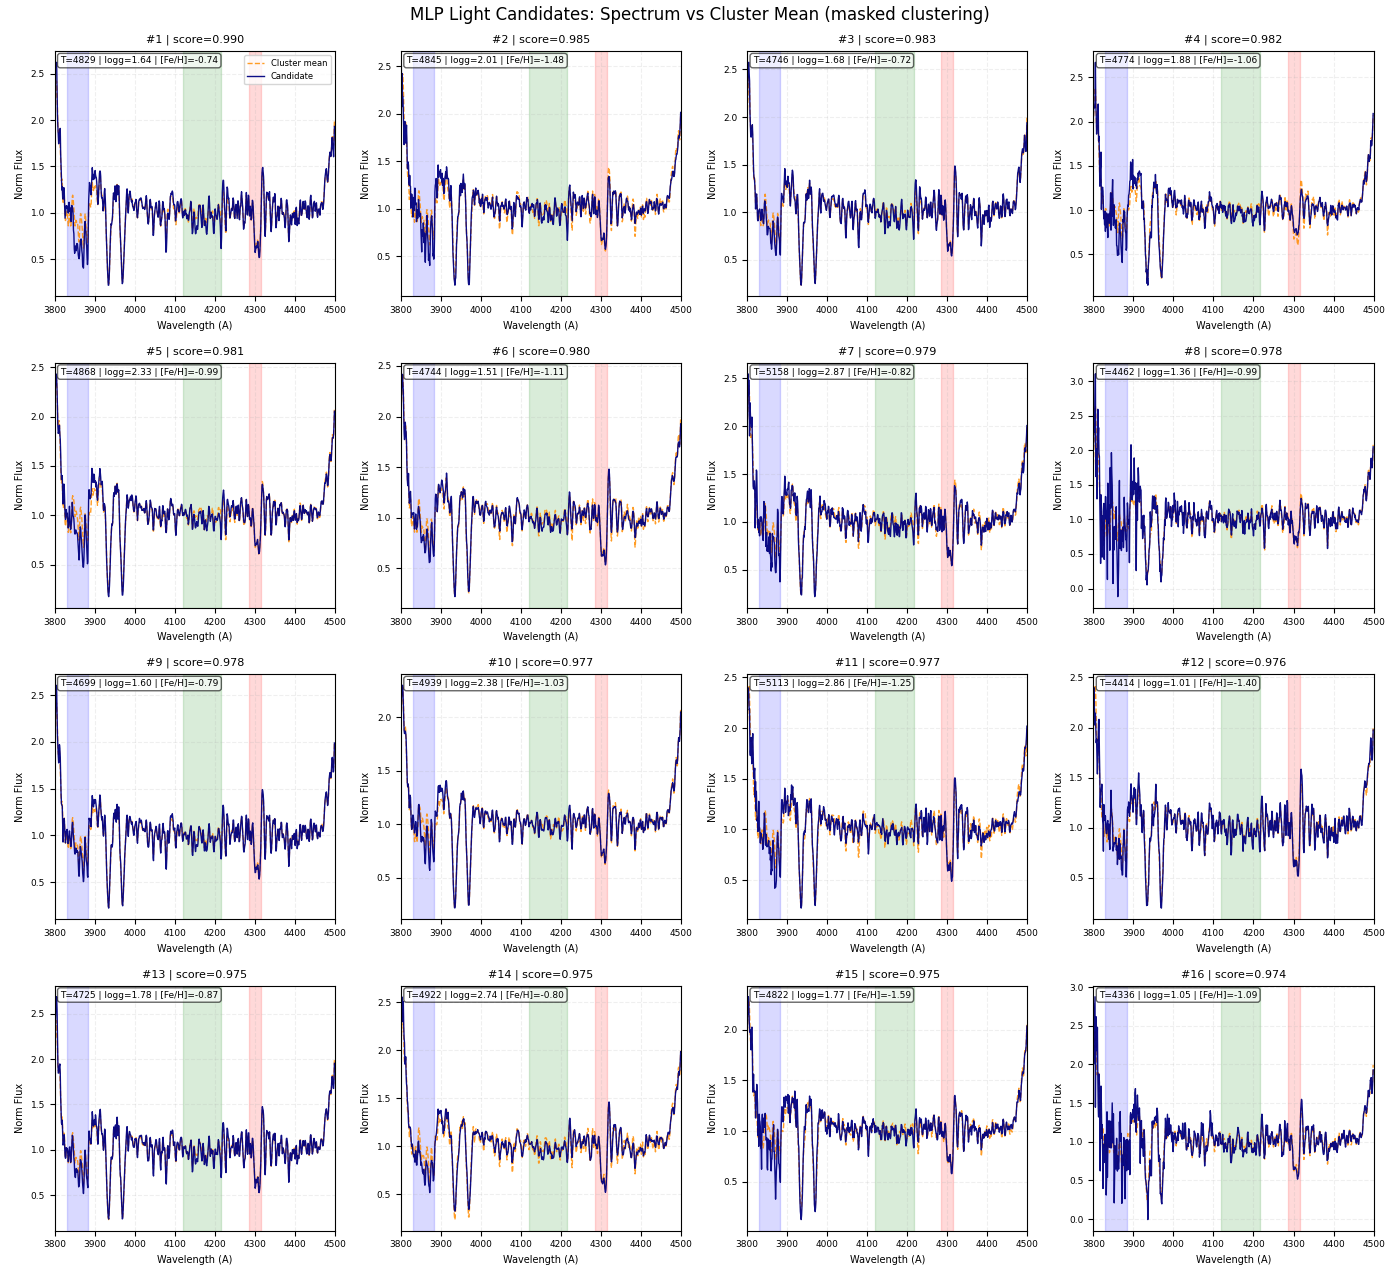

[DIAG] Matched 16/16 candidates to spectra
[DIAG] data_ok=True, score_col=final_score


In [19]:
# 候选光谱可视化：候选星 vs 所在簇平均光谱（直接用X_clean）
TOP_N_VIZ = 16

if 'masked_cluster_id' not in stars_clean.columns:
    raise RuntimeError('缺少 masked_cluster_id')

# ==== 诊断：检查数据源 ====
data_ok = False
if 'unlabeled_df_st' in globals() and len(unlabeled_df_st) > 0:
    cand_source = unlabeled_df_st.copy()
    prob_col = 'MLP_ST_prob'
    score_col = 'final_score'
    data_ok = True
    print(f'[DIAG] Using unlabeled_df_st: {len(cand_source)} rows, cols={list(cand_source.columns[:10])}...')
elif 'unlabeled_df' in globals() and len(unlabeled_df) > 0:
    cand_source = unlabeled_df.copy()
    prob_col = 'MLP_prob'
    score_col = 'MLP_prob'
    data_ok = True
    print(f'[DIAG] Using unlabeled_df: {len(cand_source)} rows, cols={list(cand_source.columns[:10])}...')
else:
    raise RuntimeError('未找到候选数据。请先运行 Cell 21（多轮训练）或 Cell 23（自训练）。')

# ==== 确保 filepath 列存在 ====
if 'filepath' not in cand_source.columns:
    print('[DIAG] filepath 列缺失，正在从 index 补齐...')
    cand_source['filepath'] = stars_clean.loc[cand_source.index, 'filepath'].values
    print(f'[DIAG] 补齐后 filepath 样例: {cand_source["filepath"].iloc[:3].tolist()}')

# 剔除 filepath 为空的
before = len(cand_source)
cand_source = cand_source.dropna(subset=['filepath'])
if len(cand_source) < before:
    print(f'[DIAG] 剔除了 {before - len(cand_source)} 个 filepath 为空的候选')

# ==== 构建簇平均光谱 ====
cluster_ids = pd.to_numeric(stars_clean['masked_cluster_id'], errors='coerce')
fp_to_idx = {fp: i for i, fp in enumerate(stars_clean['filepath'].values)}

cluster_mean_flux = {}
for cid in np.unique(cluster_ids.dropna()):
    cid = int(cid)
    m = cluster_ids.values == cid
    cluster_mean_flux[cid] = np.nanmedian(X_clean[m], axis=0)

cand_viz = cand_source.head(TOP_N_VIZ).copy()
n_matched = 0

n_cols = 4; n_rows = int(np.ceil(TOP_N_VIZ / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.2 * n_rows))
axes = np.asarray(axes).reshape(-1)

for i, (_, row) in enumerate(cand_viz.iterrows()):
    ax = axes[i]
    fp = row.get('filepath', '')

    # 分子带背景
    ax.axvspan(3830, 3883, alpha=0.15, color='blue', zorder=0)
    ax.axvspan(4120, 4216, alpha=0.15, color='green', zorder=0)
    ax.axvspan(4285, 4315, alpha=0.15, color='red', zorder=0)

    matched = False
    if fp and fp in fp_to_idx:
        idx = fp_to_idx[fp]
        cand_flux = np.asarray(X_clean[idx], dtype=float)
        cid = int(cluster_ids.iloc[idx]) if (idx < len(cluster_ids) and np.isfinite(cluster_ids.iloc[idx])) else None

        if cid is not None and cid in cluster_mean_flux:
            ax.plot(common_wave, cluster_mean_flux[cid], color='darkorange',
                    linewidth=1.0, linestyle='--', alpha=0.85, label='Cluster mean', zorder=1)

        ax.plot(common_wave, cand_flux, color='navy', linewidth=1.0, alpha=0.95, label='Candidate', zorder=2)

        if all(k in row for k in ['teff', 'logg', 'feh']) and np.isfinite(row.get('teff', np.nan)):
            txt = f"T={row['teff']:.0f} | logg={row['logg']:.2f} | [Fe/H]={row['feh']:.2f}"
            ax.text(0.02, 0.98, txt, transform=ax.transAxes, fontsize=6.5, va='top',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.6), zorder=3)
        matched = True
        n_matched += 1
    else:
        # 回退：按 DataFrame index 直接查 stars_clean
        orig_idx = row.name
        if orig_idx is not None and orig_idx < len(X_clean):
            cand_flux = np.asarray(X_clean[orig_idx], dtype=float)
            cid = int(cluster_ids.iloc[orig_idx]) if orig_idx < len(cluster_ids) and np.isfinite(cluster_ids.iloc[orig_idx]) else None
            if cid is not None and cid in cluster_mean_flux:
                ax.plot(common_wave, cluster_mean_flux[cid], color='darkorange',
                        linewidth=1.0, linestyle='--', alpha=0.85, label='Cluster mean', zorder=1)
            ax.plot(common_wave, cand_flux, color='navy', linewidth=1.0, alpha=0.95, label='Candidate', zorder=2)
            ax.text(0.02, 0.98, f'idx={orig_idx}', transform=ax.transAxes, fontsize=7, va='top',
                    bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5), zorder=3)
            matched = True
            n_matched += 1
        else:
            ax.text(0.5, 0.5, f'No match\nfp={str(fp)[:40]}\nidx={row.name}', ha='center', va='center',
                    transform=ax.transAxes, fontsize=7)

    score_val = row.get(score_col, np.nan)
    ax.set_title(f'#{i+1} | score={score_val:.3f}', fontsize=8)
    ax.set_xlim(3800, 4500); ax.set_xlabel('Wavelength (A)', fontsize=7)
    ax.set_ylabel('Norm Flux', fontsize=7); ax.tick_params(labelsize=6.5)
    ax.grid(alpha=0.2, linestyle='--')
    if i == 0 and matched:
        ax.legend(fontsize=6, loc='upper right')

for j in range(len(cand_viz), len(axes)):
    axes[j].axis('off')

fig.suptitle('MLP Light Candidates: Spectrum vs Cluster Mean (masked clustering)', fontsize=12, y=0.995)
plt.tight_layout(); plt.subplots_adjust(top=0.96); plt.show()
print(f'[DIAG] Matched {n_matched}/{len(cand_viz)} candidates to spectra')
print(f'[DIAG] data_ok={data_ok}, score_col={score_col}')


## Parameter Space Distribution — Teff-Logg 散点图

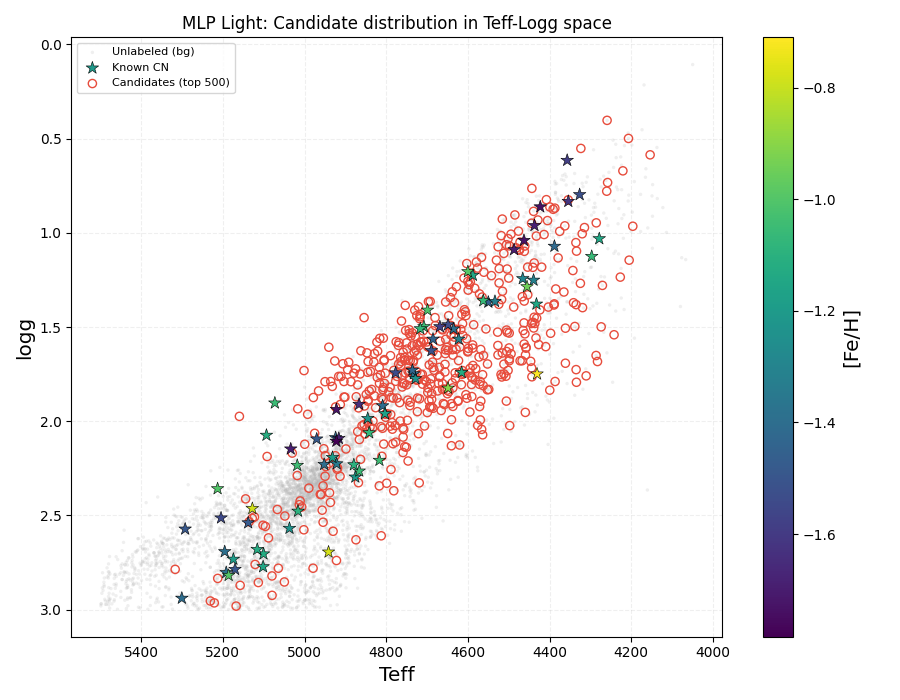

Known CN: Teff [4278, 5300], logg [0.61, 2.94]
Candidates: Teff [4154, 5317], logg [0.40, 2.98]


In [20]:
# 候选星在 Teff-Logg 空间中的分布 vs 已知CN星

# 确定数据源
if 'unlabeled_df_st' in globals() and len(unlabeled_df_st) > 0:
    cand_all = unlabeled_df_st
elif 'unlabeled_df' in globals() and len(unlabeled_df) > 0:
    cand_all = unlabeled_df
else:
    raise RuntimeError('未找到候选数据。')

# 确保 filepath
if 'filepath' not in cand_all.columns:
    cand_all['filepath'] = stars_clean.loc[cand_all.index, 'filepath'].values

cand_all = cand_all.dropna(subset=['filepath'])
cand_top_set = set(cand_all.head(500)['filepath'].values)

plot_base = stars_clean[['teff', 'logg', 'feh', 'filepath', 'label']].dropna(subset=['teff','logg','feh']).copy()

fig, ax = plt.subplots(figsize=(9, 7))

bg = plot_base[plot_base['label'] == -1]
if len(bg) > 5000:
    bg = bg.sample(5000, random_state=42)
ax.scatter(bg['teff'], bg['logg'], s=6, c='#b0b0b0', alpha=0.2, edgecolors='none', label='Unlabeled (bg)')

known_cn = plot_base[plot_base['label'] == 1]
sc = ax.scatter(known_cn['teff'], known_cn['logg'], c=known_cn['feh'], cmap='viridis',
                s=90, marker='*', edgecolors='black', linewidth=0.4, label='Known CN', zorder=3)

cand_plot = plot_base[plot_base['filepath'].isin(cand_top_set) & (plot_base['label'] == -1)]
if len(cand_plot) > 0:
    ax.scatter(cand_plot['teff'], cand_plot['logg'], facecolors='none',
               edgecolors='#e74c3c', s=35, linewidths=1.0, label=f'Candidates (top {len(cand_plot)})', zorder=2)

cbar = plt.colorbar(sc, ax=ax); cbar.set_label('[Fe/H]')
ax.set_xlabel('Teff'); ax.set_ylabel('logg')
ax.set_title('MLP Light: Candidate distribution in Teff-Logg space')
ax.invert_xaxis(); ax.invert_yaxis()
ax.grid(alpha=0.2, linestyle='--'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f'Known CN: Teff [{known_cn["teff"].min():.0f}, {known_cn["teff"].max():.0f}], logg [{known_cn["logg"].min():.2f}, {known_cn["logg"].max():.2f}]')
if len(cand_plot) > 0:
    print(f'Candidates: Teff [{cand_plot["teff"].min():.0f}, {cand_plot["teff"].max():.0f}], logg [{cand_plot["logg"].min():.2f}, {cand_plot["logg"].max():.2f}]')
